# Aplicação de um SIN para a valoração de apólice de seguro de vida.

O problema é determinar qual o preço a ser cobrado pela seguradora, frente a um determinado risco a ser identificado com a análise dos dados do cliente.
Nesse exemplo, o risco a ser avaliado será referente à **idade**, à **glicemia** e à **percentual de gordura corporal** do cliente.


In [295]:
%%html
<style>
  table > caption,
  table > tbody > tr > th {
    font-weight: bold;
  }
</style>


In [296]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
from babel.numbers import format_currency as currency, format_decimal as decimal
from IPython.display import HTML, display


## Modelagem do problema

A modelagem nebulosa do problema real compreende:

1.  definir o contexto e a questão a ser tratada. I.e., definir o problema que se quer resolver, a pergunta que se quer responder ou a decisão a ser tomada. Ainda, definir qual o contexto da questão, ou seja, definir os atores e sob quais circunstâncias, aspectos e negócio a questão está sendo percebida;

2.  definir qual a variável linguística de saída que será o resultado, resposta ou decisão da questão a ser tratada;

3.  definir os termos linguísticos (conjuntos nebulosos) da variável de saída. I.e., os possíveis valores que a variável de saída pode assumir;

4.  definir a representação dos conjuntos nebulosos da variável de saída. I.e., em geral, definir se a representação será por função de pertinência ou explícita (p. ex., listando os elementos do conjunto nebuloso em uma tabela);

5.  definir as variáveis linguísticas de entrada;

6.  definir os termos linguísticos (conjuntos nebulosos) de cada variável de entrada. I.e., os possíveis valores que as variáveis de entrada podem assumir;

7.  definir a representação dos conjuntos nebulosos das variáveis de entrada. I.e., em geral, definir se a representação será por função de pertinência ou explícita (p. ex., listando os elementos do conjunto nebuloso em uma tabela);

8.  definir as regras de inferência;

9.  definir o método de inferência que, na maioria das vezes, poderá ser Mandani ou Larsen. Mas, podem ser usado outros métodos, dependendo do problema em questão;

10. definir o método de defuzzificação.


## Definição do problema


### Contexto

- **Objetivo:** Aplicação de um SIN para a valoração de apólice de seguro de vida.
- **Pergunta:** Qual é o preço a ser cobrado pela seguradora baseado em características do cliente?
- **Atores:** Representante da companhia seguradora (decisor), e cliente (sujeito do risco).
- **Circunstâncias:** O vendedor coletará dados do cliente e fará a simulação do custo.
- **Aspectos:** Espera-se que clientes com maior tendência a precisar de procedimentos médicos precisem pagar um custo mais alto pelos serviços. Não existe uma regra absoluta perfeitamente apropriada para decidir o preço, o que leva à indicação do uso de sistemas nebulosos.


### Saída

#### Preço

**Preço** mensal para contratação do seguro de saúde.

- Dado em reais (R$).
- Intervalo aproximado de R$ 400,00 a R$ 1400,00.
- Traduz o risco associado ao cliente.

Termos linguísticos:

- Baixo
  - Custo próximo a R$ 400,00.
- Alto
  - Custo próximo a R$ 1400,00.

Representação:

- Funções de pertinência lineares.
  - Crescente para o termo `Alto`, e decrescente para o termo `Baixo`.


/home/gabriel/dev/fuzzy_systems/.venv/lib64/python3.14/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


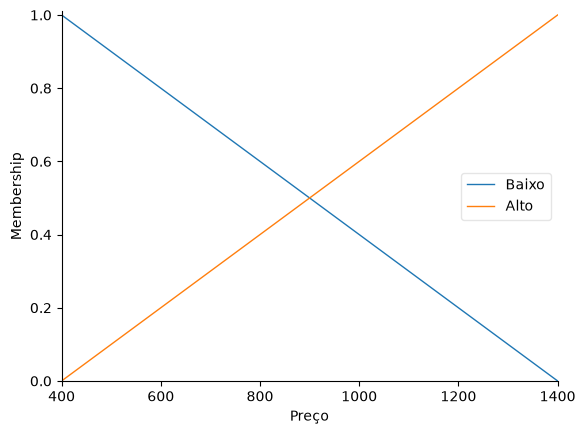

In [297]:
# Define o universo de valores.
price_universe = np.arange(400, 1401, 1)

# Define a variável.
price_variable = ctrl.Consequent(price_universe, "Preço")

# Define a função de pertinência.
price_variable["Baixo"] = fuzzy.trimf(price_variable.universe, [400, 400, 1400])
price_variable["Alto"] = fuzzy.trimf(price_variable.universe, [400, 1400, 1400])

price_variable.view()


### Entrada


#### Idade

**Idade** do cliente.

- Dado em anos.
- Intervalo aproximado de 1 a 100 anos.

Termos linguísticos:

- Jovem
  - Próximo a 10 anos.
- Adulto
  - Próximo a 40 anos.
- Idoso
  - Próximo a 70 anos.

Representação:

- Funções de pertinência lineares.
  - Decrescente para o termo `Jovem`, iniciando no início do intervalo.
  - Crescente para o termo `Idoso`, iniciando na metade do intervalo
- Função de pertinência triangular para o termo `Adulto`.
  - Crescente no início do intervalo, e passa a ser decrescente na metade.


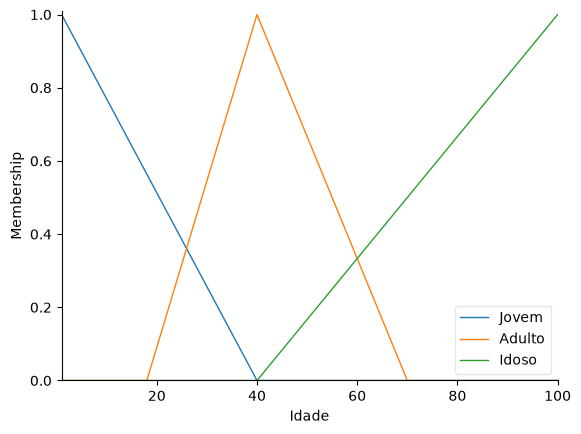

In [298]:
# Define o universo de valores.
age_universe = np.arange(1, 101, 1)

# Define a variável.
age_variable = ctrl.Antecedent(age_universe, "Idade")

# Define as funções de pertinência.

# Jovem: função linear decrescente.
age_variable["Jovem"] = fuzzy.trimf(age_universe, [1, 1, 40])

# Adulto: função triangular.
age_variable["Adulto"] = fuzzy.trimf(age_universe, [18, 40, 70])

# Idoso: função linear crescente.
age_variable["Idoso"] = fuzzy.trimf(age_universe, [40, 100, 100])

age_variable.view()

# Checagem de cobertura.
age_coverage = np.maximum.reduce(
    [age_variable["Jovem"].mf, age_variable["Adulto"].mf, age_variable["Idoso"].mf]
)
display(HTML(f"Valores sem cobertura: {age_universe[age_coverage == 0]}"))


#### Glicemia

**Glicemia** no sangue do cliente.

- Dado em mg/dL.
- Intervalo aproximado de 40 a 200 mg/dL.

Termos linguísticos:

- Hipoglicemia: < 70 mg/dL
- Normal: 70 ≤ glicemia ≤ 99
- Pré-diabetes: 100 ≤ glicemia ≤ 126
- Diabetes: > 126

Representação:

- Funções de pertinência trapezoidais conforme os valores tabelados.


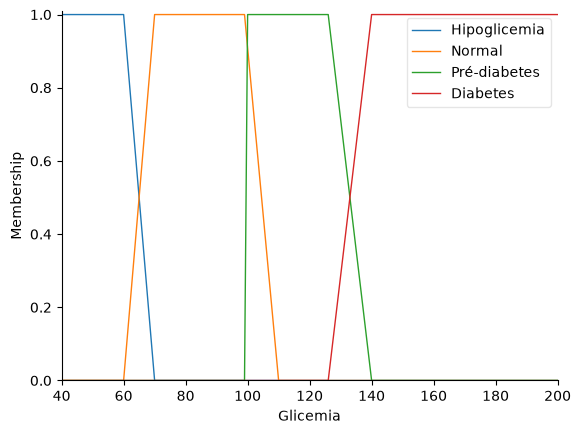

In [299]:
# Define o universo de valores.
glycemia_universe = np.arange(40, 201, 1)

# Define a variável.
glycemia_variable = ctrl.Antecedent(glycemia_universe, "Glicemia")

# Define as funções de pertinência.
glycemia_variable["Hipoglicemia"] = fuzzy.trapmf(glycemia_universe, [40, 40, 60, 70])
glycemia_variable["Normal"] = fuzzy.trapmf(glycemia_universe, [60, 70, 99, 110])
glycemia_variable["Pré-diabetes"] = fuzzy.trapmf(glycemia_universe, [99, 100, 126, 140])
glycemia_variable["Diabetes"] = fuzzy.trapmf(glycemia_universe, [126, 140, 200, 200])

glycemia_variable.view()

# Checagem de cobertura.
glycemia_coverage = np.maximum.reduce(
    [
        glycemia_variable["Hipoglicemia"].mf,
        glycemia_variable["Normal"].mf,
        glycemia_variable["Pré-diabetes"].mf,
        glycemia_variable["Diabetes"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {glycemia_universe[glycemia_coverage == 0]}"))

#### Percentual de gordura

Percentual de **gordura** no sangue do cliente.

- Dado em porcentagem.
- Intervalo de 5% a 45%.

Termos linguísticos:

- Baixo: de 5% a 21%.
- Médio: de 18% a 31%.
- Alto: de 27% a 45%.

Representação:

- Funções de pertinência trapezoidais conforme os valores tabelados.


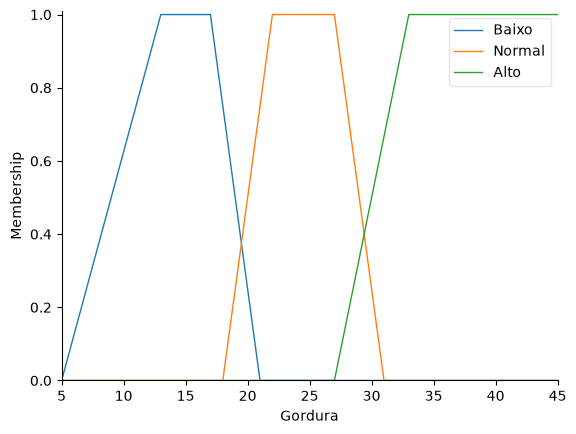

In [300]:
# Define o universo de valores.
body_fat_universe = np.arange(5, 46, 1)

# Define a variável.
body_fat_variable = ctrl.Antecedent(body_fat_universe, "Gordura")

# Define as funções de pertinência.
body_fat_variable["Baixo"] = fuzzy.trapmf(body_fat_universe, [5, 13, 17, 21])
body_fat_variable["Normal"] = fuzzy.trapmf(body_fat_universe, [18, 22, 27, 31])
body_fat_variable["Alto"] = fuzzy.trapmf(body_fat_universe, [27, 33, 45, 45])

body_fat_variable.view()

# Checagem de cobertura.
body_fat_coverage = np.maximum.reduce(
    [
        body_fat_variable["Baixo"].mf,
        body_fat_variable["Normal"].mf,
        body_fat_variable["Alto"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {body_fat_universe[body_fat_coverage == 0]}"))

## Criação de regras de inferência


### Matrizes de decisão

#### Idade: Jovem

**Gordura / Glicemia**

|            | Hipoglicemia | Normal | Pré-diabetes | Diabetes |
| ---------- | -----------: | -----: | -----------: | -------: |
| **Baixo**  |         Alto |  Baixo |        Baixo |     Alto |
| **Normal** |        Baixo |  Baixo |        Baixo |     Alto |
| **Alto**   |         Alto |  Baixo |         Alto |     Alto |

#### Idade: Adulto

**Gordura / Glicemia**

|            | Hipoglicemia | Normal | Pré-diabetes | Diabetes |
| ---------- | -----------: | -----: | -----------: | -------: |
| **Baixo**  |         Alto |  Baixo |        Baixo |     Alto |
| **Normal** |         Alto |  Baixo |         Alto |     Alto |
| **Alto**   |         Alto |   Alto |         Alto |     Alto |

#### Idade: Idoso

**Gordura \ Glicemia**

|            | Hipoglicemia | Normal | Pré-diabetes | Diabetes |
| ---------- | -----------: | -----: | -----------: | -------: |
| **Baixo**  |         Alto |   Alto |         Alto |     Alto |
| **Normal** |         Alto |  Baixo |         Alto |     Alto |
| **Alto**   |         Alto |   Alto |         Alto |     Alto |


### Definição das regras


In [301]:
# Idade: Jovem

r1 = ctrl.Rule(
    age_variable["Jovem"]
    & glycemia_variable["Hipoglicemia"]
    & body_fat_variable["Baixo"],
    price_variable["Alto"],
)
r2 = ctrl.Rule(
    age_variable["Jovem"] & glycemia_variable["Normal"] & body_fat_variable["Baixo"],
    price_variable["Baixo"],
)
r3 = ctrl.Rule(
    age_variable["Jovem"]
    & glycemia_variable["Pré-diabetes"]
    & body_fat_variable["Baixo"],
    price_variable["Baixo"],
)
r4 = ctrl.Rule(
    age_variable["Jovem"] & glycemia_variable["Diabetes"] & body_fat_variable["Baixo"],
    price_variable["Alto"],
)
r5 = ctrl.Rule(
    age_variable["Jovem"]
    & glycemia_variable["Hipoglicemia"]
    & body_fat_variable["Normal"],
    price_variable["Baixo"],
)
r6 = ctrl.Rule(
    age_variable["Jovem"] & glycemia_variable["Normal"] & body_fat_variable["Normal"],
    price_variable["Baixo"],
)
r7 = ctrl.Rule(
    age_variable["Jovem"]
    & glycemia_variable["Pré-diabetes"]
    & body_fat_variable["Normal"],
    price_variable["Baixo"],
)
r8 = ctrl.Rule(
    age_variable["Jovem"] & glycemia_variable["Diabetes"] & body_fat_variable["Normal"],
    price_variable["Alto"],
)
r9 = ctrl.Rule(
    age_variable["Jovem"]
    & glycemia_variable["Hipoglicemia"]
    & body_fat_variable["Alto"],
    price_variable["Alto"],
)
r10 = ctrl.Rule(
    age_variable["Jovem"] & glycemia_variable["Normal"] & body_fat_variable["Alto"],
    price_variable["Baixo"],
)
r11 = ctrl.Rule(
    age_variable["Jovem"]
    & glycemia_variable["Pré-diabetes"]
    & body_fat_variable["Alto"],
    price_variable["Alto"],
)
r12 = ctrl.Rule(
    age_variable["Jovem"] & glycemia_variable["Diabetes"] & body_fat_variable["Alto"],
    price_variable["Alto"],
)

# Idade: Adulto

r13 = ctrl.Rule(
    age_variable["Adulto"]
    & glycemia_variable["Hipoglicemia"]
    & body_fat_variable["Baixo"],
    price_variable["Alto"],
)
r14 = ctrl.Rule(
    age_variable["Adulto"] & glycemia_variable["Normal"] & body_fat_variable["Baixo"],
    price_variable["Baixo"],
)
r15 = ctrl.Rule(
    age_variable["Adulto"]
    & glycemia_variable["Pré-diabetes"]
    & body_fat_variable["Baixo"],
    price_variable["Baixo"],
)
r16 = ctrl.Rule(
    age_variable["Adulto"] & glycemia_variable["Diabetes"] & body_fat_variable["Baixo"],
    price_variable["Alto"],
)
r17 = ctrl.Rule(
    age_variable["Adulto"]
    & glycemia_variable["Hipoglicemia"]
    & body_fat_variable["Normal"],
    price_variable["Alto"],
)
r18 = ctrl.Rule(
    age_variable["Adulto"] & glycemia_variable["Normal"] & body_fat_variable["Normal"],
    price_variable["Baixo"],
)
r19 = ctrl.Rule(
    age_variable["Adulto"]
    & glycemia_variable["Pré-diabetes"]
    & body_fat_variable["Normal"],
    price_variable["Alto"],
)
r20 = ctrl.Rule(
    age_variable["Adulto"]
    & glycemia_variable["Diabetes"]
    & body_fat_variable["Normal"],
    price_variable["Alto"],
)
r21 = ctrl.Rule(
    age_variable["Adulto"]
    & glycemia_variable["Hipoglicemia"]
    & body_fat_variable["Alto"],
    price_variable["Alto"],
)
r22 = ctrl.Rule(
    age_variable["Adulto"] & glycemia_variable["Normal"] & body_fat_variable["Alto"],
    price_variable["Alto"],
)
r23 = ctrl.Rule(
    age_variable["Adulto"]
    & glycemia_variable["Pré-diabetes"]
    & body_fat_variable["Alto"],
    price_variable["Alto"],
)
r24 = ctrl.Rule(
    age_variable["Adulto"] & glycemia_variable["Diabetes"] & body_fat_variable["Alto"],
    price_variable["Alto"],
)

# Idade: Idoso

r25 = ctrl.Rule(
    age_variable["Idoso"]
    & glycemia_variable["Hipoglicemia"]
    & body_fat_variable["Baixo"],
    price_variable["Alto"],
)
r26 = ctrl.Rule(
    age_variable["Idoso"] & glycemia_variable["Normal"] & body_fat_variable["Baixo"],
    price_variable["Alto"],
)
r27 = ctrl.Rule(
    age_variable["Idoso"]
    & glycemia_variable["Pré-diabetes"]
    & body_fat_variable["Baixo"],
    price_variable["Alto"],
)
r28 = ctrl.Rule(
    age_variable["Idoso"] & glycemia_variable["Diabetes"] & body_fat_variable["Baixo"],
    price_variable["Alto"],
)
r29 = ctrl.Rule(
    age_variable["Idoso"]
    & glycemia_variable["Hipoglicemia"]
    & body_fat_variable["Normal"],
    price_variable["Alto"],
)
r30 = ctrl.Rule(
    age_variable["Idoso"] & glycemia_variable["Normal"] & body_fat_variable["Normal"],
    price_variable["Baixo"],
)
r31 = ctrl.Rule(
    age_variable["Idoso"]
    & glycemia_variable["Pré-diabetes"]
    & body_fat_variable["Normal"],
    price_variable["Alto"],
)
r32 = ctrl.Rule(
    age_variable["Idoso"] & glycemia_variable["Diabetes"] & body_fat_variable["Normal"],
    price_variable["Alto"],
)
r33 = ctrl.Rule(
    age_variable["Idoso"]
    & glycemia_variable["Hipoglicemia"]
    & body_fat_variable["Alto"],
    price_variable["Alto"],
)
r34 = ctrl.Rule(
    age_variable["Idoso"] & glycemia_variable["Normal"] & body_fat_variable["Alto"],
    price_variable["Alto"],
)
r35 = ctrl.Rule(
    age_variable["Idoso"]
    & glycemia_variable["Pré-diabetes"]
    & body_fat_variable["Alto"],
    price_variable["Alto"],
)
r36 = ctrl.Rule(
    age_variable["Idoso"] & glycemia_variable["Diabetes"] & body_fat_variable["Alto"],
    price_variable["Alto"],
)

# Compilação

rules = [
    r1,
    r2,
    r3,
    r4,
    r5,
    r6,
    r7,
    r8,
    r9,
    r10,
    r11,
    r12,
    r13,
    r14,
    r15,
    r16,
    r17,
    r18,
    r19,
    r20,
    r21,
    r22,
    r23,
    r24,
    r25,
    r26,
    r27,
    r28,
    r29,
    r30,
    r31,
    r32,
    r33,
    r34,
    r35,
    r36,
]


## Simulação

### Controle


In [302]:
### Método de controle

price_ctrl = ctrl.ControlSystem(rules)
price_simulation = ctrl.ControlSystemSimulation(price_ctrl)


def predict_price(age: int, glycemia: float, body_fat: float):
    price_simulation.input["Idade"] = age
    price_simulation.input["Glicemia"] = glycemia
    price_simulation.input["Gordura"] = body_fat
    price_simulation.compute()
    return price_simulation.output["Preço"]


def simulate_and_display(
    age: int,
    glycemia: float,
    body_fat: float,
    plot_input: bool = False,
    plot_output=False,
):
    prediction = predict_price(age=age, glycemia=glycemia, body_fat=body_fat)
    display(
        HTML(
            f"""<table><caption>Simulação de preço de seguro de saúde.</caption>
                    <thead>
                        <tr><th>Idade</th><th>Glicemia (mg/dL)</th><th>Gordura (%)</th><th>Preço (R$)</th></tr>
                    </thead>
                    <tbody>
                        <tr><td>{age}</td><td>{decimal(glycemia, locale="pt_BR")}</td><td>{decimal(body_fat, locale="pt_BR")}</td><td>{currency(prediction, "BRL", locale="pt_BR")}</td>
                    </tbody>
                </table>"""
        )
    )
    if plot_input:
        age_variable.view(sim=price_simulation)
        glycemia_variable.view(sim=price_simulation)
        body_fat_variable.view(sim=price_simulation)
    if plot_output:
        price_variable.view(sim=price_simulation)


def simulate_and_display_many(data):
    rows = []

    for age, glycemia, body_fat in data:
        prediction = predict_price(age=age, glycemia=glycemia, body_fat=body_fat)

        rows.append(
            f"""
            <tr>
                <td>{age}</td>
                <td>{decimal(glycemia, locale="pt_BR")}</td>
                <td>{decimal(body_fat, locale="pt_BR")}</td>
                <td>{currency(prediction, "BRL", locale="pt_BR")}</td>
            </tr>
            """
        )

    display(
        HTML(
            f"""
            <table>
                <caption>Simulação de preço de seguro de saúde.</caption>
                <thead>
                    <tr>
                        <th>Idade</th>
                        <th>Glicemia (mg/dL)</th>
                        <th>Gordura (%)</th>
                        <th>Preço (R$)</th>
                    </tr>
                </thead>
                <tbody>
                    {"".join(rows)}
                </tbody>
            </table>
            """
        )
    )

In [303]:
simulate_and_display(age=28, glycemia=85, body_fat=30)


Idade,Glicemia (mg/dL),Gordura (%),Preço (R$)
28,85,30,"R$ 943,12"


### Método de inferência

Foi decidido utilizar o método de Mamdani, que é o padrão da biblioteca.


Idade,Glicemia (mg/dL),Gordura (%),Preço (R$)
28,85,30,"R$ 943,12"


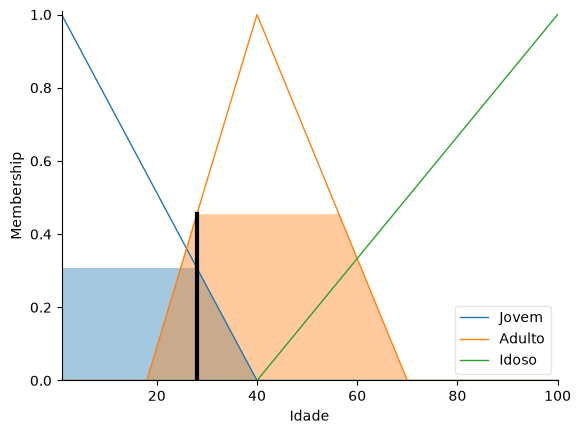

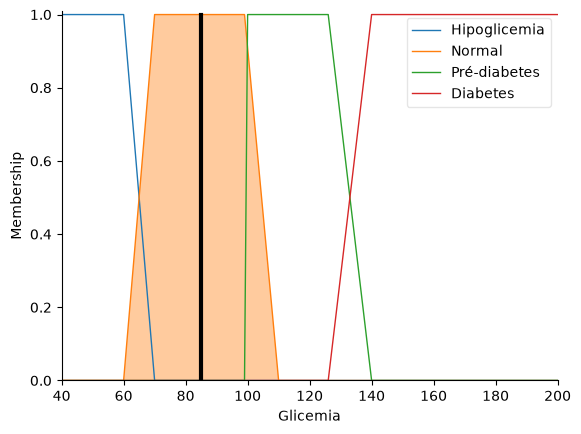

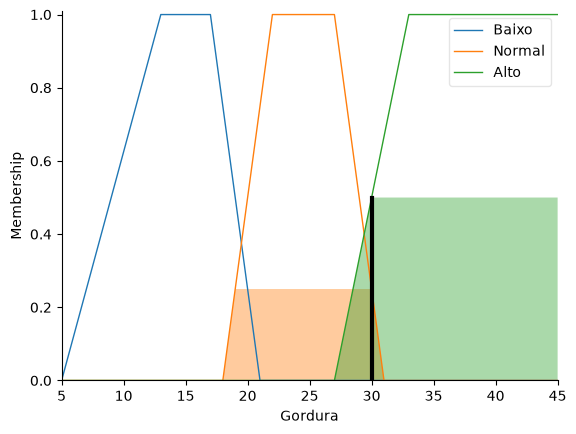

In [304]:
simulate_and_display(age=28, glycemia=85, body_fat=30, plot_input=True)


### Defuzzificação

Foi decidido utilizar o método de Centroide, que é o padrão da biblioteca.


Idade,Glicemia (mg/dL),Gordura (%),Preço (R$)
28,85,30,"R$ 943,12"


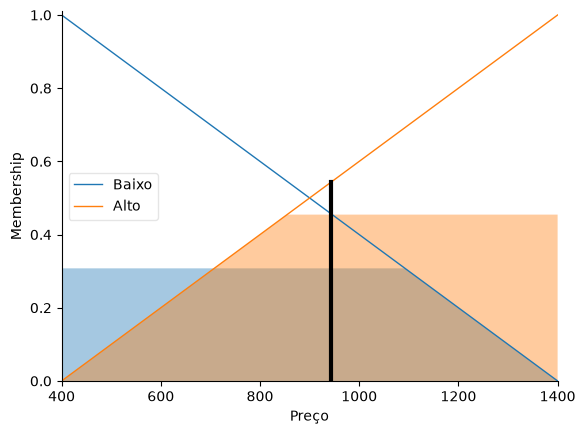

In [305]:
simulate_and_display(age=28, glycemia=85, body_fat=30, plot_output=True)


## Exemplos


In [307]:
simulate_and_display_many(
    data=[
        (16, 70, 20),
        (28, 85, 30),
        (25, 85, 12),
        (35, 105, 22),
        (55, 130, 28),
        (75, 150, 35),
    ]
)


Idade,Glicemia (mg/dL),Gordura (%),Preço (R$)
16,70,20,"R$ 788,89"
28,85,30,"R$ 943,12"
25,85,12,"R$ 811,48"
35,105,22,"R$ 962,99"
55,130,28,"R$ 1.011,11"
75,150,35,"R$ 1.025,82"
